# Methane Detection: Matched Filter

This notebook applies a **Matched Filter (MF)** to Tanager SWIR bands (~2300 nm) to detect methane (CH4) absorption features.

### Theory
The matched filter computes a per-pixel score:

$$MF(x) = \\frac{t^T \\Sigma^{-1} (x - \\mu)}{t^T \\Sigma^{-1} t}$$

Where:
- $x$ = pixel spectrum (radiance vector)
- $\\mu$ = mean background spectrum
- $\\Sigma$ = background covariance matrix
- $t$ = methane target signature

**Sign convention:** methane *absorbs*, so the radiance perturbation is negative.
The target is built as $t = -k \\odot \\mu$, where $k$ is the absorption coefficient
spectrum and $\\mu$ is the background mean. The Hadamard product matters: the
perturbation scales with how bright the surface underneath was, so an unweighted
target preferentially latches onto dark pixels. With this convention, positive MF
scores indicate absorption.

### Pipeline
1. Load scene and isolate SWIR bands (2050-2450 nm)
2. Estimate background mean and covariance (must run before step 3 - target needs `mu`)
3. Build CH4 target signature
4. Apply matched filter across all pixels
5. Threshold to produce plume mask
6. **Spectral ratio diagnostic** - confirm the detection is gas, not albedo
7. Visualize and save


## Imports & Load Scene

In [20]:
import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
import os

# ── Paths ──────────────────────────────────────────────────────────────────
SCENE_PATH = "../data/raw/20250205_175845_00_4001_basic_radiance.h5"
OUTPUT_DIR  = "../outputs/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load scene ─────────────────────────────────────────────────────────────
def load_tanager_scene(filepath):
    with h5py.File(filepath, "r") as f:
        toa            = f["HDFEOS/SWATHS/HYP/Data Fields/toa_radiance"]
        radiance       = toa[:]                      # (bands, lines, samples)
        wavelengths_nm = toa.attrs["wavelengths"]    # nm
        lat = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude"][:]
        lon = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude"][:]
    ds = xr.Dataset(
        {"radiance": (["band", "line", "sample"], radiance)},
        coords={
            "wavelength_nm": ("band", wavelengths_nm),
            "lat": (["line", "sample"], lat),
            "lon": (["line", "sample"], lon),
        }
    )
    return ds

ds = load_tanager_scene(SCENE_PATH)
print(f"Scene shape: {ds['radiance'].shape}  (bands, lines, samples)")
print(f"Wavelength range: {ds['wavelength_nm'].values[0]:.1f} – {ds['wavelength_nm'].values[-1]:.1f} nm")
print(f"Lat range: {ds['lat'].values.min():.3f} – {ds['lat'].values.max():.3f}")
print(f"Lon range: {ds['lon'].values.min():.3f} – {ds['lon'].values.max():.3f}")

Scene shape: (426, 680, 607)  (bands, lines, samples)
Wavelength range: 376.4 – 2499.0 nm
Lat range: 32.738 – 33.015
Lon range: -104.049 – -103.760


## Isolate SWIR Bands for CH₄ Detection

SWIR bands selected: 81  (2051.9 – 2449.4 nm)
Scene spatial dimensions: 680 lines × 607 samples


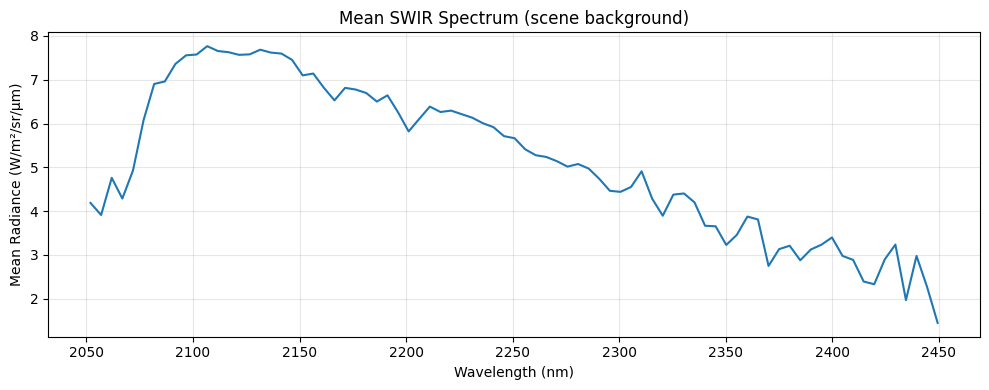

In [21]:
# CH₄ has strong absorption features in the 2050–2450 nm SWIR window
WL_MIN, WL_MAX = 2050, 2450

wl  = ds["wavelength_nm"].values
rad = ds["radiance"].values      # (bands, lines, samples)

# Mask to SWIR bands
swir_mask = (wl >= WL_MIN) & (wl <= WL_MAX)
wl_swir   = wl[swir_mask]                    # (n_swir_bands,)
rad_swir  = rad[swir_mask, :, :]             # (n_swir_bands, lines, samples)

n_bands, n_lines, n_samples = rad_swir.shape
print(f"SWIR bands selected: {n_bands}  ({wl_swir[0]:.1f} – {wl_swir[-1]:.1f} nm)")
print(f"Scene spatial dimensions: {n_lines} lines × {n_samples} samples")

# Replace fill values with NaN
rad_swir = rad_swir.astype(np.float32)
rad_swir[rad_swir == -9999.0] = np.nan

# Quick SWIR mean-spectrum plot to check data quality
mean_spectrum = np.nanmean(rad_swir, axis=(1, 2))
plt.figure(figsize=(10, 4))
plt.plot(wl_swir, mean_spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Radiance (W/m²/sr/µm)")
plt.title("Mean SWIR Spectrum (scene background)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mean_swir_spectrum.png", dpi=150)
plt.show()

## Estimate Background Statistics

In [ ]:
# Reshape to (n_pixels, n_bands) for linear algebra
n_bands, n_lines, n_samples = rad_swir.shape
X = rad_swir.reshape(n_bands, -1).T   # (n_pixels, n_bands)

# Remove pixels with any NaN (fill values, bad data)
valid_mask = ~np.any(np.isnan(X), axis=1)
X_valid = X[valid_mask]             # (n_valid_pixels, n_bands)

print(f"Total pixels:  {X.shape[0]:,}")
print(f"Valid pixels:  {X_valid.shape[0]:,}  ({100*X_valid.shape[0]/X.shape[0]:.1f}%)")

# Background mean and covariance
mu = np.mean(X_valid, axis=0)       # (n_bands,)
X_c = X_valid - mu                  # mean-centered

# Use numpy for covariance — for large scenes consider sklearn or chunked approach
cov = np.cov(X_c.T)                 # (n_bands, n_bands)

# Regularize covariance (add small diagonal to ensure invertibility)
reg = 1e-4 * np.trace(cov) / n_bands
cov += reg * np.eye(n_bands)

# Invert covariance
cov_inv = np.linalg.inv(cov)

print(f"Background mean shape:  {mu.shape}")
print(f"Covariance matrix shape: {cov.shape}")
print(f"Regularization term: {reg:.6f}")

Total pixels:  412,760
Valid pixels:  412,760  (100.0%)
Background mean shape:  (81,)
Covariance matrix shape: (81, 81)
Regularization term: 0.000023


## Build CH₄ Target Signature

We construct a unit absorption spectrum for CH₄ using a simplified Beer-Lambert model.
For a production analysis, replace this with HITRAN line-by-line or a pre-computed
transmittance lookup table (e.g. from MODTRAN or atmosphere-rt).

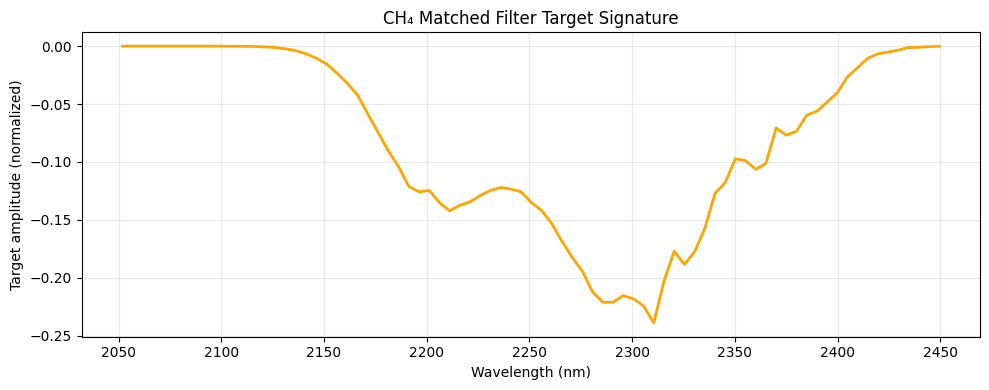

Target vector shape: (81,)
Target vector norm: 1.0000


In [ ]:
def build_ch4_absorption_coeffs(wavelengths_nm):
    """
    Unit CH4 absorption coefficient spectrum (dimensionless, per unit column).
    Placeholder Gaussians at the main SWIR bands — replace with HITRAN
    (via hapi) before final submission.
    """
    wl = wavelengths_nm
    k = np.zeros(len(wl))
    k += 1.0 * np.exp(-0.5 * ((wl - 2304) / 40) ** 2)
    k += 0.4 * np.exp(-0.5 * ((wl - 2204) / 25) ** 2)
    k += 0.3 * np.exp(-0.5 * ((wl - 2380) / 20) ** 2)
    return k


# Target = NEGATIVE, and scaled by background radiance (Beer-Lambert linearization)
k = build_ch4_absorption_coeffs(wl_swir)
ch4_target = -k * mu          # mu = background mean spectrum from Cell 4
ch4_target = ch4_target / (np.linalg.norm(ch4_target) + 1e-12)


plt.figure(figsize=(10, 4))
plt.plot(wl_swir, ch4_target, color="orange", linewidth=2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Target amplitude (normalized)")
plt.title("CH₄ Matched Filter Target Signature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ch4_target_signature.png", dpi=150)
plt.show()

print(f"Target vector shape: {ch4_target.shape}")
print(f"Target vector norm: {np.linalg.norm(ch4_target):.4f}")

## Apply Matched Filter

In [24]:
def apply_matched_filter(X, mu, cov_inv, target):
    """
    Apply matched filter to all pixels.

    MF(x) = [t^T Σ⁻¹ (x - μ)] / [t^T Σ⁻¹ t]

    Parameters
    ----------
    X        : (n_pixels, n_bands)  — all pixel spectra
    mu       : (n_bands,)           — background mean
    cov_inv  : (n_bands, n_bands)   — inverse covariance
    target   : (n_bands,)           — CH₄ target signature

    Returns
    -------
    mf_scores : (n_pixels,)  — matched filter score per pixel
    """
    X_c = X - mu                              # mean-center
    t   = target

    # Numerator: t^T Σ⁻¹ (x - μ) for all pixels at once
    Sigma_inv_t = cov_inv @ t                 # (n_bands,)
    numerator   = X_c @ Sigma_inv_t           # (n_pixels,)

    # Denominator: scalar t^T Σ⁻¹ t
    denominator = t @ Sigma_inv_t             # scalar

    return numerator / (denominator + 1e-12)


# Apply to all pixels (including NaN pixels — will produce NaN scores)
mf_scores_flat = np.full(X.shape[0], np.nan)
mf_scores_flat[valid_mask] = apply_matched_filter(
    X_valid, mu, cov_inv, ch4_target
)

# Reshape back to spatial grid
mf_map = mf_scores_flat.reshape(n_lines, n_samples)

print(f"MF score map shape: {mf_map.shape}")
print(f"Score range (valid): {np.nanmin(mf_map):.4f} – {np.nanmax(mf_map):.4f}")
print(f"Score mean:  {np.nanmean(mf_map):.4f}")
print(f"Score stdev: {np.nanstd(mf_map):.4f}")

MF score map shape: (680, 607)
Score range (valid): -0.6909 – 3.1884
Score mean:  -0.0001
Score stdev: 0.0783


## Threshold & Detect Plumes

In [25]:
# Detection threshold: pixels > mean + N*sigma flagged as potential plumes
# Typically N=3 for initial screening; raise to 5 for high-confidence detections
N_SIGMA = 2.0  # Was 3.0

mf_mean  = np.nanmean(mf_map)
mf_std   = np.nanstd(mf_map)
threshold = mf_mean + N_SIGMA * mf_std

plume_mask = mf_map > threshold

# Optional: light spatial smoothing to reduce salt-and-pepper noise
mf_smooth = gaussian_filter(np.nan_to_num(mf_map, nan=0.0), sigma=1.5)
plume_mask_smooth = mf_smooth > threshold

print(f"Detection threshold ({N_SIGMA}σ): {threshold:.4f}")
print(f"Plume pixels (raw):     {plume_mask.sum():,}  ({100*plume_mask.sum()/valid_mask.sum():.2f}% of valid)")
print(f"Plume pixels (smoothed): {plume_mask_smooth.sum():,}")

Detection threshold (2.0σ): 0.1564
Plume pixels (raw):     9,176  (2.22% of valid)
Plume pixels (smoothed): 737


## Spectral Ratio Diagnostic

Before trusting any detection, check whether the flagged pixels actually show
band-differential methane absorption or are simply darker than their surroundings.


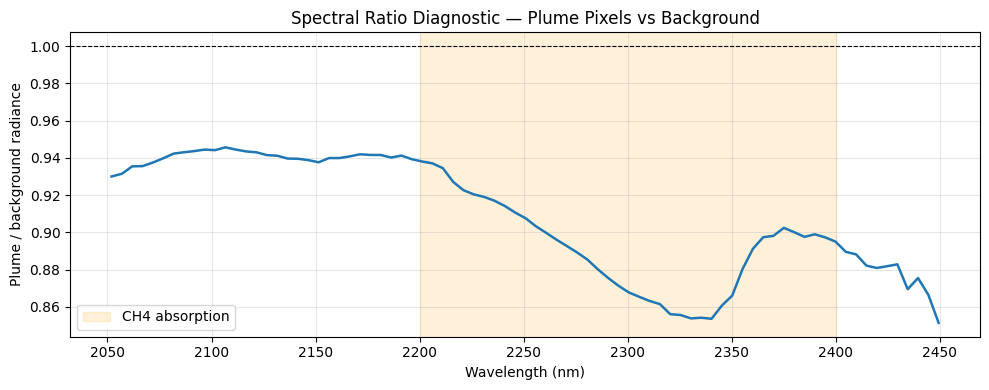

Mean ratio outside CH4 bands: 0.924
Mean ratio inside  CH4 bands: 0.892
Interpretation: a clean gas signature has the inside value clearly
below the outside value. Similar values indicate a dark-surface confound.


In [ ]:
# Diagnostic: is this gas, or just dark ground?
# Real CH4 shows band-differential absorption: ratio near 1.0 outside
# 2200-2400 nm, dipping inside it. A flat depression across the whole
# window is an albedo/shadow confound, not methane.

pm = plume_mask_smooth.ravel()

plume_spec = np.nanmean(X[pm & valid_mask], axis=0)
bg_spec    = np.nanmean(X[(~pm) & valid_mask], axis=0)
ratio      = plume_spec / bg_spec

plt.figure(figsize=(10, 4))
plt.plot(wl_swir, ratio, lw=1.8)
plt.axhline(1.0, color="k", ls="--", lw=0.8)
plt.axvspan(2200, 2400, alpha=0.15, color="orange", label="CH4 absorption")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Plume / background radiance")
plt.title("Spectral Ratio Diagnostic — Plume Pixels vs Background")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spectral_ratio_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean ratio outside CH4 bands: "
      f"{np.nanmean(ratio[(wl_swir < 2200) | (wl_swir > 2400)]):.3f}")
print(f"Mean ratio inside  CH4 bands: "
      f"{np.nanmean(ratio[(wl_swir >= 2200) & (wl_swir <= 2400)]):.3f}")
print("Interpretation: a clean gas signature has the inside value clearly")
print("below the outside value. Similar values indicate a dark-surface confound.")


Brightness-matched  outside: 0.990
Brightness-matched  inside:  0.959
Differential: 0.0314


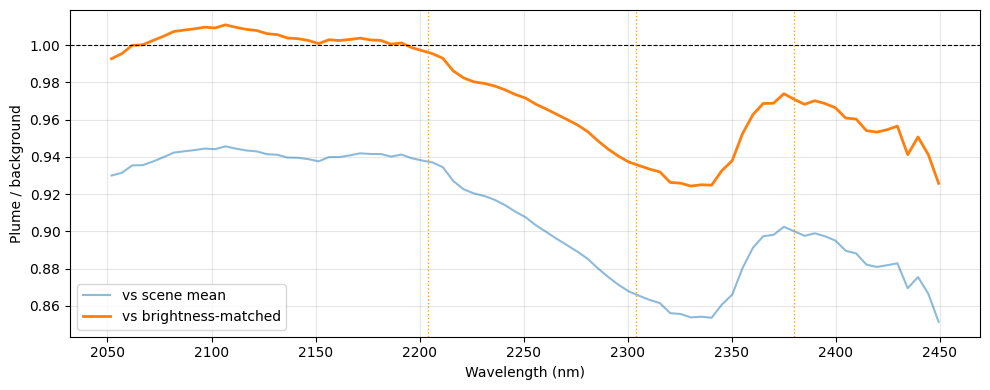

In [29]:
from scipy.spatial import cKDTree

# Brightness proxy from continuum only (outside CH4 bands)
cont   = (wl_swir < 2150) | (wl_swir > 2420)
bright = np.nanmean(X[:, cont], axis=1)

pm        = plume_mask_smooth.ravel()
plume_idx = np.where(pm & valid_mask)[0]
bg_idx    = np.where((~pm) & valid_mask)[0]

# For each plume pixel, pull the 25 background pixels closest in brightness
tree   = cKDTree(bright[bg_idx][:, None])
_, nn  = tree.query(bright[plume_idx][:, None], k=25)
matched_bg = bg_idx[nn.ravel()]

ratio_m = np.nanmean(X[plume_idx], axis=0) / np.nanmean(X[matched_bg], axis=0)

inside  = (wl_swir >= 2200) & (wl_swir <= 2400)
outside = ~inside
print(f"Brightness-matched  outside: {np.nanmean(ratio_m[outside]):.3f}")
print(f"Brightness-matched  inside:  {np.nanmean(ratio_m[inside]):.3f}")
print(f"Differential: {np.nanmean(ratio_m[outside]) - np.nanmean(ratio_m[inside]):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(wl_swir, ratio, lw=1.5, alpha=0.5, label="vs scene mean")
plt.plot(wl_swir, ratio_m, lw=2, label="vs brightness-matched")
plt.axhline(1.0, color="k", ls="--", lw=0.8)
for c_wl in (2204, 2304, 2380):
    plt.axvline(c_wl, color="orange", ls=":", lw=1)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Plume / background")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Visualize MF Score Map & Detections

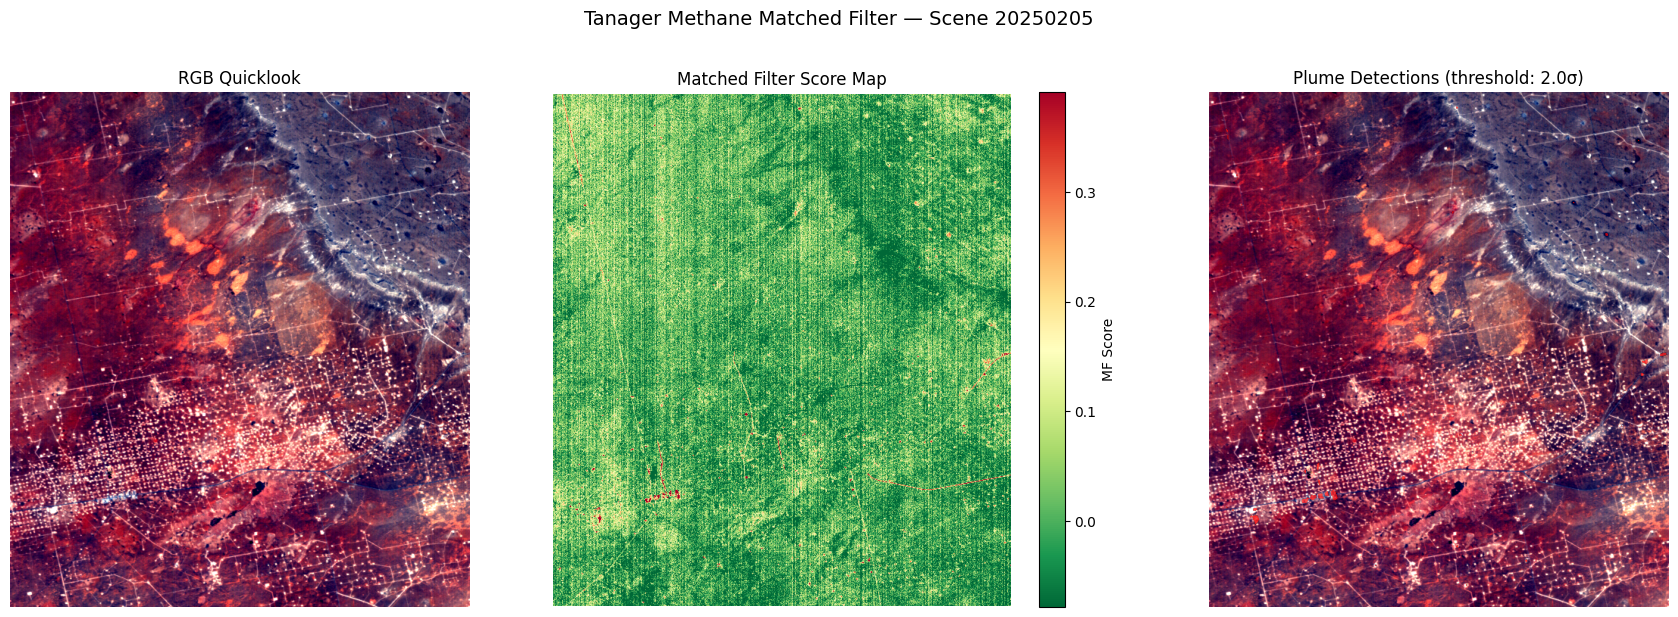

Saved: ../outputs/figures/matched_filter_results.png


In [ ]:
# Build RGB background for context
wl_full = ds["wavelength_nm"].values
rad_full = ds["radiance"].values

r_idx = np.argmin(np.abs(wl_full - 650))
g_idx = np.argmin(np.abs(wl_full - 550))
b_idx = np.argmin(np.abs(wl_full - 450))

rgb = np.stack([rad_full[r_idx], rad_full[g_idx], rad_full[b_idx]], axis=-1).astype(np.float32)
rgb[rgb == -9999.0] = np.nan
p2, p98 = np.nanpercentile(rgb, [2, 98])
rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

# Plot 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: RGB quicklook
axes[0].imshow(rgb)
axes[0].set_title("RGB Quicklook")
axes[0].axis("off")

# Panel 2: Raw MF score map
vmax = mf_mean + 5 * mf_std
im = axes[1].imshow(mf_map, cmap="RdYlGn_r", vmin=mf_mean - mf_std, vmax=vmax)
plt.colorbar(im, ax=axes[1], label="MF Score")
axes[1].set_title("Matched Filter Score Map")
axes[1].axis("off")

# Panel 3: RGB and plume overlay
axes[2].imshow(rgb)
plume_overlay = np.zeros((*mf_map.shape, 4))  # RGBA
plume_overlay[plume_mask_smooth, 0] = 1.0     # Red channel
plume_overlay[plume_mask_smooth, 3] = 0.7     # Alpha
axes[2].imshow(plume_overlay)
axes[2].set_title(f"Plume Detections (threshold: {N_SIGMA}σ)")
axes[2].axis("off")

plt.suptitle("Tanager Methane Matched Filter — Scene 20250205", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/matched_filter_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/matched_filter_results.png")

## Save MF Results for Next Step (IME Quantification)

In [28]:
import pandas as pd

# Save MF map as numpy array for use in notebook 04
os.makedirs("../data/processed", exist_ok=True)
np.save("../data/processed/mf_map_20250205.npy", mf_map)
np.save("../data/processed/plume_mask_20250205.npy", plume_mask_smooth)

# Save lat/lon of plume pixels to CSV for facility attribution
plume_rows, plume_cols = np.where(plume_mask_smooth)
lat_arr = ds["lat"].values
lon_arr = ds["lon"].values

plume_df = pd.DataFrame({
    "row":      plume_rows,
    "col":      plume_cols,
    "lat":      lat_arr[plume_rows, plume_cols],
    "lon":      lon_arr[plume_rows, plume_cols],
    "mf_score": mf_map[plume_rows, plume_cols],
})

plume_df.to_csv("../data/processed/plume_pixels_20250205.csv", index=False)
print(f"Saved MF map, plume mask, and {len(plume_df):,} plume pixel coordinates.")
print(plume_df.describe())

Saved MF map, plume mask, and 737 plume pixel coordinates.
              row         col         lat         lon    mf_score
count  737.000000  737.000000  737.000000  737.000000  737.000000
mean   458.461330  214.755767   32.840795 -103.948091    0.323616
std    146.753561  174.959506    0.049131    0.071462    0.267010
min     19.000000   18.000000   32.765244 -104.029164   -0.172631
25%    423.000000  124.000000   32.817698 -103.986353    0.157138
50%    530.000000  146.000000   32.819496 -103.978244    0.264409
75%    538.000000  257.000000   32.849089 -103.929301    0.431289
max    651.000000  603.000000   33.002921 -103.776043    3.188394


## HITRAN Validation: Is the Absorption Feature Actually Methane?

The brightness-matched control confirmed a real 3.1% absorption feature, but its
minimum sits near 2335 nm with a recovery at 2380 nm — a shape that does not match
the placeholder Gaussian target used for detection. Here we compare the observed
absorption depth against a HITRAN-derived CH4 spectrum convolved to Tanager's
~5.5 nm FWHM.

**Decision rule:** correlation above ~0.8 with coincident peaks indicates methane,
and the matched filter should be rebuilt from this spectrum. Correlation below ~0.5,
or a peak offset from HITRAN's, indicates a surface mineralogy feature (calcite
absorbs near 2340 nm, and caliche soils are common in the Permian).

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CH4
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/reference/hitran/CH4.data
  65536 bytes written to ../data/ref

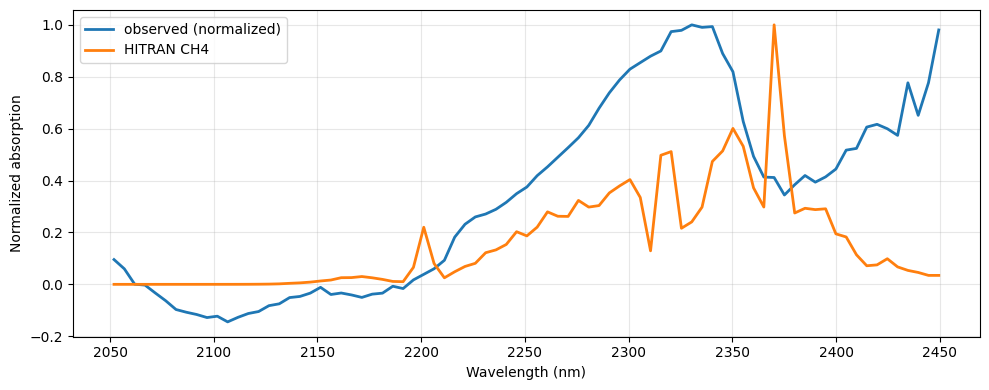

In [31]:
# pip install hitran-api
from hapi import db_begin, fetch, absorptionCoefficient_Voigt
import numpy as np

db_begin('../data/reference/hitran')
fetch('CH4', 6, 1, 4080, 4880)          # cm-1, covers 2050-2450 nm

nu, coef = absorptionCoefficient_Voigt(
    SourceTables='CH4', Environment={'p': 1.0, 'T': 288.0},
    WavenumberStep=0.01, HITRAN_units=False
)

wl_h = 1e7 / nu                          # cm-1 -> nm
o = np.argsort(wl_h)
wl_h, k_h = wl_h[o], coef[o]

# Convolve to Tanager's ~5.5 nm FWHM, then resample to our bands
sigma = 5.5 / 2.355

W = np.exp(-0.5 * ((wl_h[None, :] - wl_swir[:, None]) / sigma) ** 2)   # (n_bands, n_hitran)
k_conv = np.trapezoid(W * k_h[None, :], wl_h, axis=1) / np.trapezoid(W, wl_h, axis=1)
k_conv /= k_conv.max()

# Observed absorption depth vs HITRAN CH4
depth = 1.0 - ratio_m
r = np.corrcoef(depth, k_conv)[0, 1]
print(f"Correlation with HITRAN CH4: {r:.3f}")

plt.figure(figsize=(10, 4))
plt.plot(wl_swir, depth / depth.max(), lw=2, label="observed (normalized)")
plt.plot(wl_swir, k_conv, lw=2, label="HITRAN CH4")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Normalized absorption")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Notes & Next Steps

**Improving the target signature:**
For a more rigorous analysis, replace `build_ch4_absorption_coeffs()` with a HITRAN-derived
transmittance spectrum. The `hapi` library (HITRAN API) can generate this:
```bash
pip install hapi
```

**Next notebook:** `04_ime_quantification.ipynb`
- Use the plume mask to define plume extent
- Apply the **Integrated Mass Enhancement (IME)** method with ERA5 wind data
- Estimate emission rates in kg CH₄/hr per detected plume